# TFT Full-Run Sanity Check

This notebook checks the full `tft/artifacts` outputs and plots one random user's train history, test actuals, and test predictions.

In [13]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

def first_existing(paths):
    for path in paths:
        if path.exists():
            return path
    return paths[0]

artifacts_root = first_existing([Path("tft/artifacts"), Path("artifacts")])
data_root = artifacts_root / "data"
eval_root = artifacts_root / "eval"
infer_root = artifacts_root / "infer"
final_root = artifacts_root / "final"
models_root = artifacts_root / "models"

print(f"artifacts_root = {artifacts_root.resolve()}")

core_paths = {
    "split_boundaries": data_root / "split_boundaries.json",
    "leakage_audit": data_root / "leakage_audit.json",
    "shared_panel": data_root / "shared_panel.parquet",
    "cluster_10_panel": data_root / "cluster_10_panel.parquet",
    "cluster_12_panel": data_root / "cluster_12_panel.parquet",
    "shared_ckpt": models_root / "tft_shared_pretrain" / "checkpoints" / "best.ckpt",
    "c10_ckpt": models_root / "tft_c10_ft" / "checkpoints" / "best.ckpt",
    "c12_ckpt": models_root / "tft_c12_ft" / "checkpoints" / "best.ckpt",
    "final_test": final_root / "user_level_test_predictions.parquet",
    "final_future": final_root / "user_level_future_predictions_14d.parquet",
    "final_all": final_root / "user_level_predictions_all.parquet",
    "final_metrics_by_period": final_root / "multiphase_metrics_by_period.parquet",
    "final_metrics_overall": final_root / "multiphase_metrics_overall.parquet",
}

for name, path in core_paths.items():
    print(f"{name:28s} -> {path.exists()}  {path}")

artifacts_root = D:\MSDS\2026spring\Forecasting\Project2\Electricity-Load-Prediction\tft\artifacts
split_boundaries             -> True  artifacts\data\split_boundaries.json
leakage_audit                -> True  artifacts\data\leakage_audit.json
shared_panel                 -> True  artifacts\data\shared_panel.parquet
cluster_10_panel             -> True  artifacts\data\cluster_10_panel.parquet
cluster_12_panel             -> True  artifacts\data\cluster_12_panel.parquet
shared_ckpt                  -> True  artifacts\models\tft_shared_pretrain\checkpoints\best.ckpt
c10_ckpt                     -> True  artifacts\models\tft_c10_ft\checkpoints\best.ckpt
c12_ckpt                     -> True  artifacts\models\tft_c12_ft\checkpoints\best.ckpt
final_test                   -> True  artifacts\final\user_level_test_predictions.parquet
final_future                 -> True  artifacts\final\user_level_future_predictions_14d.parquet
final_all                    -> True  artifacts\final\user_level_

In [14]:
with open(data_root / "split_boundaries.json", "r", encoding="utf-8") as f:
    split_boundaries = json.load(f)

with open(data_root / "leakage_audit.json", "r", encoding="utf-8") as f:
    leakage_audit = json.load(f)

print("split_boundaries")
print(json.dumps(split_boundaries, indent=2, ensure_ascii=False))

print("\nleakage_audit")
print(json.dumps(leakage_audit, indent=2, ensure_ascii=False))

split_boundaries
{
  "train_wide_path": "data\\train_hourly_preprocessed.parquet",
  "test_wide_path": "data\\test_hourly_preprocessed.parquet",
  "clusters_path": "data\\extended-clustering-high-cov\\clusters_3models.parquet",
  "cluster_ids": [
    10,
    12
  ],
  "test_months_detected": [
    "2014-10",
    "2014-11",
    "2014-12"
  ],
  "train_start": "2013-01-01 00:00:00",
  "train_end": "2014-06-30 23:00:00",
  "val_start": "2014-07-01 00:00:00",
  "val_end": "2014-09-30 23:00:00",
  "test_start": "2014-10-01 00:00:00",
  "test_end": "2014-12-31 23:00:00",
  "future_start": "2015-01-01 00:00:00",
  "future_end": "2015-01-14 23:00:00",
  "train_rows": 327600,
  "val_rows": 55200,
  "test_rows": 55200,
  "future_rows": 8400,
  "user_count": 25,
  "cluster_user_counts": {
    "10": 7,
    "12": 18
  },
  "dropped_cluster_users_missing_in_panels": []
}

leakage_audit
{
  "test_month_window_valid": true,
  "time_order_valid": true,
  "feature_shift_valid": true,
  "train_fit_only_v

In [15]:
manifest_files = [
    models_root / "tft_shared_pretrain" / "train_manifest.json",
    models_root / "tft_c10_ft" / "finetune_manifest.json",
    models_root / "tft_c12_ft" / "finetune_manifest.json",
]

for path in manifest_files:
    print(f"\n=== {path.name} ===")
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            print(json.dumps(json.load(f), indent=2, ensure_ascii=False))
    else:
        print("missing")


=== train_manifest.json ===
{
  "run_name": "tft_shared_pretrain",
  "panel_path": "tft\\artifacts\\data\\shared_panel.parquet",
  "dataset_params_path": "tft\\artifacts\\models\\tft_shared_pretrain\\dataset_params.pt",
  "best_checkpoint_path": "D:\\MSDS\\2026spring\\Forecasting\\Project2\\Electricity-Load-Prediction\\tft\\artifacts\\models\\tft_shared_pretrain\\checkpoints\\best-v1.ckpt",
  "train_end_idx": 13103,
  "val_start_idx": 13104,
  "val_end_idx": 15311
}

=== finetune_manifest.json ===
{
  "run_name": "tft_c10_ft",
  "cluster_id": 10,
  "panel_path": "tft\\artifacts\\data\\cluster_10_panel.parquet",
  "shared_dataset_params_path": "tft\\artifacts\\models\\tft_shared_pretrain\\dataset_params.pt",
  "pretrained_checkpoint_path": "tft\\artifacts\\models\\tft_shared_pretrain\\checkpoints\\best.ckpt",
  "best_checkpoint_path": "D:\\MSDS\\2026spring\\Forecasting\\Project2\\Electricity-Load-Prediction\\tft\\artifacts\\models\\tft_c10_ft\\checkpoints\\best.ckpt",
  "train_end_idx"

In [16]:
shared_panel = pd.read_parquet(data_root / "shared_panel.parquet")
c10_panel = pd.read_parquet(data_root / "cluster_10_panel.parquet")
c12_panel = pd.read_parquet(data_root / "cluster_12_panel.parquet")

for name, df in {
    "shared_panel": shared_panel,
    "cluster_10_panel": c10_panel,
    "cluster_12_panel": c12_panel,
}.items():
    print(f"\n{name}")
    print(df.shape)
    print(df[["timestamp", "user_id", "cluster_id", "split", "time_idx"]].head())
    print(df["split"].value_counts(dropna=False).sort_index())


shared_panel
(446400, 24)
            timestamp user_id  cluster_id  split  time_idx
0 2013-01-01 00:00:00  MT_090          10  train         0
1 2013-01-01 01:00:00  MT_090          10  train         1
2 2013-01-01 02:00:00  MT_090          10  train         2
3 2013-01-01 03:00:00  MT_090          10  train         3
4 2013-01-01 04:00:00  MT_090          10  train         4
split
future      8400
test       55200
train     327600
val        55200
Name: count, dtype: int64

cluster_10_panel
(124992, 24)
            timestamp user_id  cluster_id  split  time_idx
0 2013-01-01 00:00:00  MT_090          10  train         0
1 2013-01-01 01:00:00  MT_090          10  train         1
2 2013-01-01 02:00:00  MT_090          10  train         2
3 2013-01-01 03:00:00  MT_090          10  train         3
4 2013-01-01 04:00:00  MT_090          10  train         4
split
future     2352
test      15456
train     91728
val       15456
Name: count, dtype: int64

cluster_12_panel
(321408, 24)
       

In [17]:
eval_files = {
    "c10_pred": eval_root / "tft_c10_ft" / "tft_c10_ft_cluster_10_test_predictions.parquet",
    "c10_overall": eval_root / "tft_c10_ft" / "tft_c10_ft_cluster_10_test_metrics_overall.parquet",
    "c10_by_period": eval_root / "tft_c10_ft" / "tft_c10_ft_cluster_10_test_metrics_by_period.parquet",
    "c10_by_user_period": eval_root / "tft_c10_ft" / "tft_c10_ft_cluster_10_test_metrics_by_user_period.parquet",
    "c12_pred": eval_root / "tft_c12_ft" / "tft_c12_ft_cluster_12_test_predictions.parquet",
    "c12_overall": eval_root / "tft_c12_ft" / "tft_c12_ft_cluster_12_test_metrics_overall.parquet",
    "c12_by_period": eval_root / "tft_c12_ft" / "tft_c12_ft_cluster_12_test_metrics_by_period.parquet",
    "c12_by_user_period": eval_root / "tft_c12_ft" / "tft_c12_ft_cluster_12_test_metrics_by_user_period.parquet",
}

for name, path in eval_files.items():
    print(f"{name:22s} -> {path.exists()}  {path}")

c10_pred               -> True  artifacts\eval\tft_c10_ft\tft_c10_ft_cluster_10_test_predictions.parquet
c10_overall            -> True  artifacts\eval\tft_c10_ft\tft_c10_ft_cluster_10_test_metrics_overall.parquet
c10_by_period          -> True  artifacts\eval\tft_c10_ft\tft_c10_ft_cluster_10_test_metrics_by_period.parquet
c10_by_user_period     -> True  artifacts\eval\tft_c10_ft\tft_c10_ft_cluster_10_test_metrics_by_user_period.parquet
c12_pred               -> True  artifacts\eval\tft_c12_ft\tft_c12_ft_cluster_12_test_predictions.parquet
c12_overall            -> True  artifacts\eval\tft_c12_ft\tft_c12_ft_cluster_12_test_metrics_overall.parquet
c12_by_period          -> True  artifacts\eval\tft_c12_ft\tft_c12_ft_cluster_12_test_metrics_by_period.parquet
c12_by_user_period     -> True  artifacts\eval\tft_c12_ft\tft_c12_ft_cluster_12_test_metrics_by_user_period.parquet


In [18]:
c10_overall = pd.read_parquet(eval_files["c10_overall"])
c10_by_period = pd.read_parquet(eval_files["c10_by_period"])
c12_overall = pd.read_parquet(eval_files["c12_overall"])
c12_by_period = pd.read_parquet(eval_files["c12_by_period"])
final_test = pd.read_parquet(final_root / "user_level_test_predictions.parquet")
final_future = pd.read_parquet(final_root / "user_level_future_predictions_14d.parquet")
final_all = pd.read_parquet(final_root / "user_level_predictions_all.parquet")
final_metrics_by_period = pd.read_parquet(final_root / "multiphase_metrics_by_period.parquet")
final_metrics_overall = pd.read_parquet(final_root / "multiphase_metrics_overall.parquet")

print("c10 overall")
display(c10_overall)

print("c10 by period")
display(c10_by_period)

print("c12 overall")
display(c12_overall)

print("c12 by period")
display(c12_by_period)

print("final test / future / all shapes")
print({
    "final_test": final_test.shape,
    "final_future": final_future.shape,
    "final_all": final_all.shape,
})

print("final_all split counts")
print(final_all["split"].value_counts(dropna=False).sort_index())

print("final_all phase counts")
print(final_all["phase"].value_counts(dropna=False).sort_index())

print("final multiphase metrics by period")
display(final_metrics_by_period)

print("final multiphase metrics overall")
display(final_metrics_overall)

c10 overall


,model_name,cluster_id,period,MAPE_0_100,EPSILON_MAPE_PCT,WMAPE_0_100,n_obs,n_positive
0,tft_c10_ft,10,OVERALL,22.674136,1.867857e+06,15.824538,185808,185785


c10 by period


,model_name,cluster_id,period,MAPE_0_100,EPSILON_MAPE_PCT,WMAPE_0_100,n_obs,n_positive
0,tft_c10_ft,10,P1,22.280342,5.335492e+06,15.796794,57624,57615
1,tft_c10_ft,10,P2,22.859432,3.340419e+01,15.280439,70560,70560
2,tft_c10_ft,10,P3,22.841038,6.873519e+05,16.494346,57624,57610


c12 overall


...

,model_name,cluster_id,period,MAPE_0_100,EPSILON_MAPE_PCT,WMAPE_0_100,n_obs,n_positive
0,tft_c12_ft,12,P1,15.078702,1.763946e+06,12.402999,148176,147618
1,tft_c12_ft,12,P2,16.959472,4.114630e+07,13.485099,181440,180194
2,tft_c12_ft,12,P3,22.110534,1.065373e+08,18.683660,148176,146965


final test / future / all shapes
{'final_test': (663600, 9), 'final_future': (8400, 10), 'final_all': (672000, 12)}
final_all split counts
split
future      8400
test      663600
Name: count, dtype: int64
final_all phase counts
phase
FUTURE      8400
P1        205800
P2        252000
P3        205800
Name: count, dtype: int64
final multiphase metrics by period


,model_name,cluster_id,period,MAPE_0_100,EPSILON_MAPE_PCT,WMAPE_0_100,n_obs,n_positive
0,tft_c10_ft,10,P1,22.280342,5.335492e+06,15.796794,57624,57615
1,tft_c10_ft,10,P2,22.859432,3.340419e+01,15.280439,70560,70560
2,tft_c10_ft,10,P3,22.841038,6.873519e+05,16.494346,57624,57610
3,tft_c12_ft,12,P1,15.078702,1.763946e+06,12.402999,148176,147618
4,tft_c12_ft,12,P2,16.959472,4.114630e+07,13.485099,181440,180194
5,tft_c12_ft,12,P3,22.110534,1.065373e+08,18.683660,148176,146965


final multiphase metrics overall


,model_name,cluster_id,period,MAPE_0_100,EPSILON_MAPE_PCT,WMAPE_0_100,n_obs,n_positive
0,tft_c10_ft,10,OVERALL,22.674136,1.867857e+06,15.824538,185808,185785
1,tft_c12_ft,12,OVERALL,17.973676,4.921227e+07,14.727217,477792,474777


In [19]:
rng = np.random.default_rng(42)
random_user_id = rng.choice(final_test["user_id"].dropna().astype(str).unique())

user_test_raw = final_test.loc[final_test["user_id"].astype(str) == str(random_user_id)].copy()
user_test_raw["timestamp"] = pd.to_datetime(user_test_raw["timestamp"])

# Rolling test evaluation can emit multiple predictions for the same timestamp.
# Aggregate to one line per hour for a readable plot.
user_test = (
    user_test_raw.groupby("timestamp", as_index=False)
    .agg(
        actual=("actual", "first"),
        prediction=("prediction", "median"),
        cluster_id=("cluster_id", "first"),
        model_name=("model_name", "first"),
        n_predictions=("prediction", "size"),
    )
    .sort_values("timestamp")
)

cluster_id = int(user_test["cluster_id"].iloc[0])
panel_path = data_root / f"cluster_{cluster_id}_panel.parquet"
panel_df = pd.read_parquet(panel_path)
panel_df["timestamp"] = pd.to_datetime(panel_df["timestamp"])

user_train = (
    panel_df.loc[
        (panel_df["user_id"].astype(str) == str(random_user_id)) & (panel_df["split"] == "train"),
        ["timestamp", "target_load"],
    ]
    .rename(columns={"target_load": "train_actual"})
    .sort_values("timestamp")
)

train_tail_days = 60
train_cutoff = user_test["timestamp"].min() - pd.Timedelta(days=train_tail_days)
user_train_tail = user_train.loc[user_train["timestamp"] >= train_cutoff].copy()

print({
    "random_user_id": str(random_user_id),
    "cluster_id": cluster_id,
    "model_name": user_test["model_name"].iloc[0],
    "test_rows_after_aggregation": len(user_test),
    "median_predictions_per_timestamp": float(user_test["n_predictions"].median()),
})

display(user_test.head())

{'random_user_id': 'MT_159', 'cluster_id': 10, 'model_name': 'tft_c10_ft', 'test_rows_after_aggregation': 2208, 'median_predictions_per_timestamp': 14.0}


,timestamp,actual,prediction,cluster_id,model_name,n_predictions
0,2014-10-01 00:00:00,380.536398,398.2500,10,tft_c10_ft,1
1,2014-10-01 01:00:00,190.737548,429.5000,10,tft_c10_ft,1
2,2014-10-01 02:00:00,103.524904,107.1250,10,tft_c10_ft,1
3,2014-10-01 03:00:00,90.105364,86.8125,10,tft_c10_ft,1
4,2014-10-01 04:00:00,80.517241,78.0625,10,tft_c10_ft,1


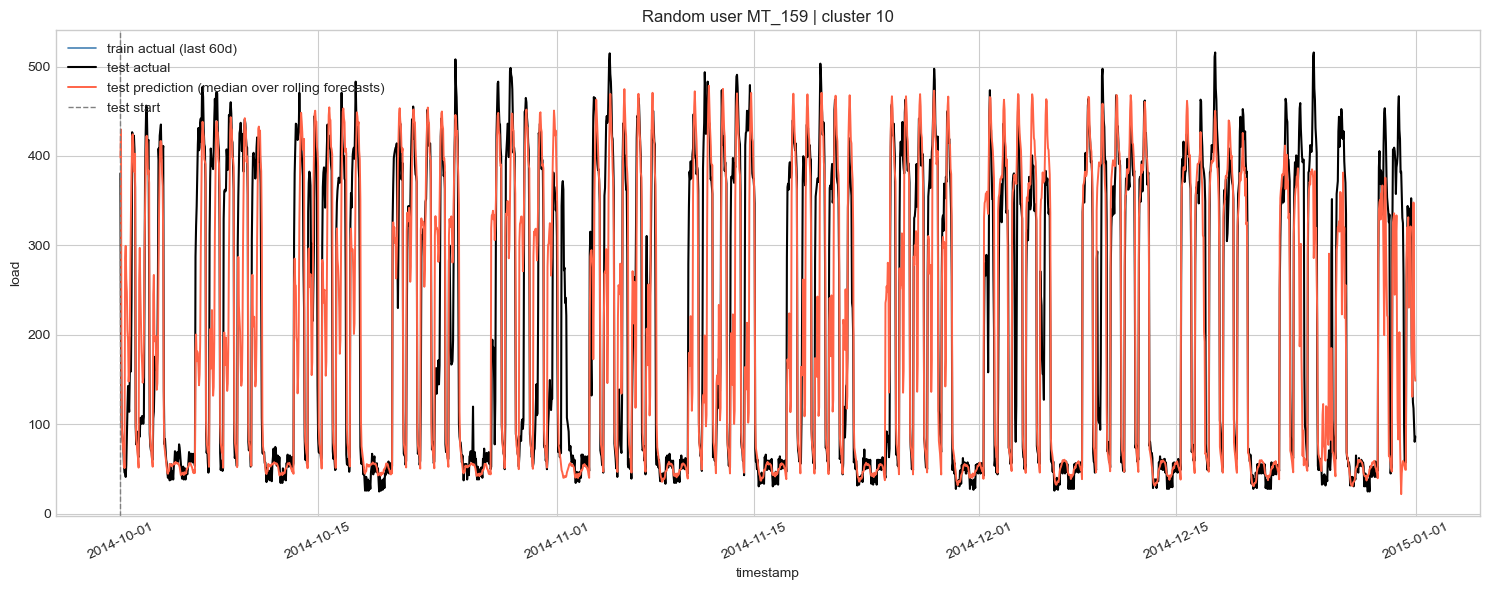

In [20]:
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(
    user_train_tail["timestamp"],
    user_train_tail["train_actual"],
    label=f"train actual (last {train_tail_days}d)",
    color="steelblue",
    linewidth=1.2,
)
ax.plot(
    user_test["timestamp"],
    user_test["actual"],
    label="test actual",
    color="black",
    linewidth=1.5,
)
ax.plot(
    user_test["timestamp"],
    user_test["prediction"],
    label="test prediction (median over rolling forecasts)",
    color="tomato",
    linewidth=1.4,
)
ax.axvline(user_test["timestamp"].min(), color="gray", linestyle="--", linewidth=1.0, label="test start")
ax.set_title(f"Random user {random_user_id} | cluster {cluster_id}")
ax.set_xlabel("timestamp")
ax.set_ylabel("load")
ax.legend(loc="upper left")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()